## Clustering

k-mean clustering

In [66]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import pandas as pd

In [67]:
X, y_true = make_blobs(n_samples=500, n_features=2, random_state=42, centers=4, cluster_std=1)

In [68]:
df = pd.DataFrame(X, columns=["feature1", "feature2"])
df.head()

,feature1,feature2
0,-7.689054,6.620346
1,-9.576514,-6.934404
2,6.829682,1.164871
3,-2.901306,7.550771
4,-5.678413,-7.288185


In [69]:

columns = ["feature1", "feature2"]
scaler = StandardScaler()

scaledData = scaler.fit_transform(df[columns])
df2 = pd.DataFrame(scaledData, columns = ["feature1", "feature2"])
df2.head()

,feature1,feature2
0,-0.815393,0.589390
1,-1.173444,-1.553288
2,1.938811,-0.272989
3,0.092842,0.736467
4,-0.433975,-1.609212


### Elbow method

In [70]:
k = [2,3,4,5,6,7,8,9]
inertia = []
for i in k: 
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaledData)
    inertia.append(kmeans.inertia_)

In [71]:
inertia

[558.0851064442198,
 116.09567852755524,
 28.786938978874012,
 26.19113104232202,
 23.019557612855962,
 20.635126042351732,
 17.89005415894658,
 16.846839891702263]

<Axes: >

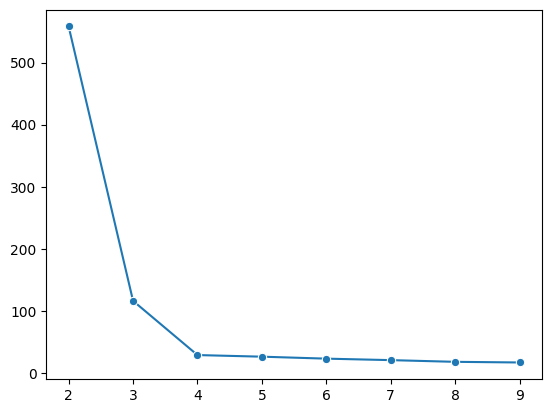

In [72]:
sns.lineplot(x=k, y=inertia, marker='o' )

In [73]:
model = KMeans(n_clusters=4, random_state=42)
model.fit(scaledData)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [74]:
df2['labels'] = model.labels_


In [75]:
df2.head()

,feature1,feature2,labels
0,-0.815393,0.589390,1
1,-1.173444,-1.553288,2
2,1.938811,-0.272989,0
3,0.092842,0.736467,3
4,-0.433975,-1.609212,2


<Axes: xlabel='feature1', ylabel='feature2'>

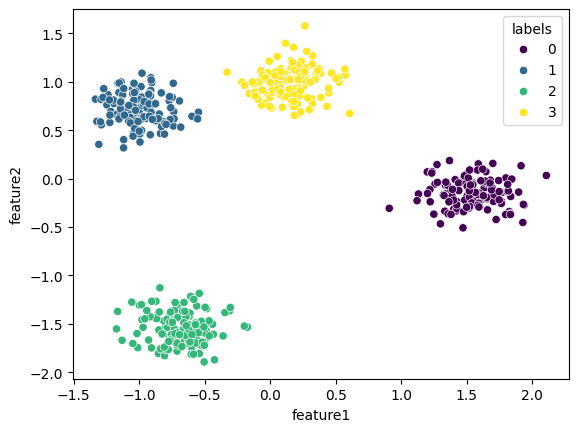

In [78]:
sns.scatterplot(data=df2, x="feature1", y="feature2", hue="labels", palette="viridis")